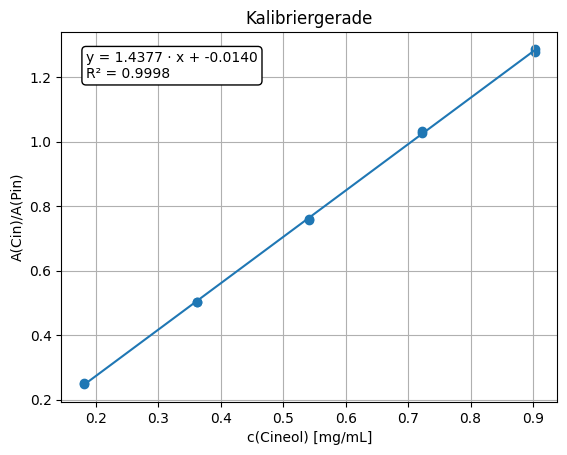

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel(
    "Template_GC.xlsx",
    engine="openpyxl",
    usecols="B,F",    # B = c(Cineol), F = A/A
    skiprows=3,      # Startzeile
    nrows=12         # Anzahl Datenzeilen
)

df.columns = ["c", "A_ratio"]

x = df["c"]
y = df["A_ratio"]

# ===============================
# Lineare Regression
# ===============================
m, b = np.polyfit(x, y, 1)      # Steigung & Achsenabschnitt
y_fit = m * x + b

# Bestimmtheitsmaß R²
y_mean = np.mean(y)
r2 = np.sum((y_fit - y_mean)**2) / np.sum((y - y_mean)**2)

# ===============================
# Plot
# ===============================
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_fit)

plt.xlabel("c(Cineol) [mg/mL]")
plt.ylabel("A(Cin)/A(Pin)")
plt.title("Kalibriergerade")
plt.grid(True)

# Geradengleichung ins Diagramm schreiben
plt.text(
    0.05, 0.95,
    f"y = {m:.4f} · x + {b:.4f}\nR² = {r2:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white")
)

plt.show()

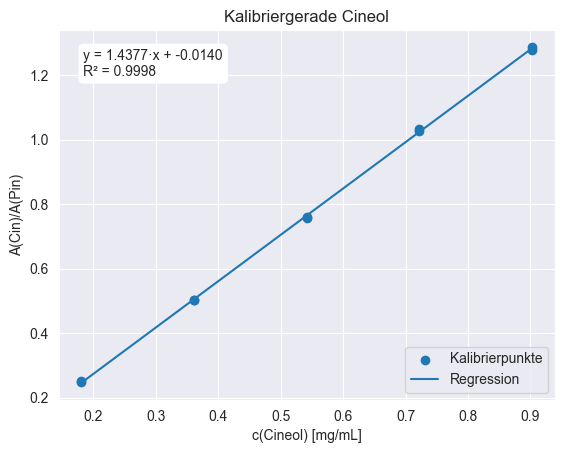

=== Darstellung der Kalibriergerade ===
Steigung b               = 1.437679
Ordinatenabschnitt a     = -0.014023
Bestimmtheitsmaß R²      = 0.9998
Korrelationskoeffizient R= 0.9999
Reststandardabweichung sy= 0.005494
Quadratsumme Qxx         = 0.651854
Anzahl Kalibriermessung n= 10
Freiheitsgrade f         = 8
t-Wert (einseitig, 95 %) = 1.8595
t-Wert (zweiseitig, 95 %)= 2.3060

=== Nachweis- / Bestimmungsgrenze (nach Folienformeln) ===
LOD Messlösung x_NG [mg/mL] = 6.679092e-03
LOQ Messlösung x_BG [g/mL] = 2.438401e-02
LOD Öl [mg/mL]             = 1.113182e+01  (mit D = 1666.6667)
LOQ Öl [g/mL]             = 4.064002e+01  (mit D = 1666.6667)


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# ===============================
# 1) Daten laden
# ===============================
df = pd.read_excel(
    "Template_GC.xlsx",
    engine="openpyxl",
    usecols="B,F",    # B = c(Cineol), F = A(Cin)/A(Pin)
    skiprows=3,       # ggf. anpassen, falls andere Startzeile
    nrows=12          # Anzahl Kalibrierpunkte
)

df.columns = ["c", "A_ratio"]   # x und y

x = df["c"].to_numpy()
y = df["A_ratio"].to_numpy()

# ===============================
# 2) Lineare Regression
# ===============================
# y = b * x + a
b, a = np.polyfit(x, y, 1)      # b = Steigung, a = Achsenabschnitt
y_fit = b * x + a

# Korrelationskoeffizient R und R^2
R = np.corrcoef(x, y)[0, 1]
R2 = R**2

# ===============================
# 3) Statistik: sy, Qxx, n, f, t-Werte
# ===============================
n = len(x)               # Anzahl Kalibriermessungen
f = n - 2                # Freiheitsgrade bei einfacher Regression

sy = np.sqrt(np.sum((y - y_fit)**2) / (n - 2)) # Reststandardabweichung

x_mean = np.mean(x)
Qxx = np.sum((x - x_mean)**2)           # Quadratsumme Qxx

# t-Werte für 95 % (alpha = 0.05)
alpha = 0.05
t_einseitig = t.ppf(1 - alpha, df=f)
t_zweiseitig = t.ppf(1 - alpha/2, df=f)

# ===============================
# 4) LOD (x_NG) und LOQ (x_BG) nach Folienformeln
# ===============================

m = 3          # Anzahl Probenmessungen
k = 3.0        # Faktor für LOQ

# --- LOD (Nachweisgrenze) in mg/mL ---
x_NG = (sy / abs(b)) * t_einseitig * np.sqrt(
    1/n + 1/m + (x_mean**2) / Qxx
)

# --- LOQ (Bestimmungsgrenze) in mg/mL ---
x_BG = k * (sy / abs(b)) * t_zweiseitig * np.sqrt(
    1/n + 1/m + ((k * x_NG - x_mean)**2) / Qxx
)

# ===============================
# Umrechnung auf das Öl
# ===============================
D = 1666.6667   # dein Verdünnungsfaktor

# LOD bleibt in mg/mL
LOD_mess_mg_ml = x_NG
LOD_oel_mg_ml  = LOD_mess_mg_ml * D

# LOQ soll in g/mL sein
LOQ_mess_mg_ml = x_BG
LOQ_mess_g_ml  = LOQ_mess_mg_ml / 1000      # mg → g
LOQ_oel_g_ml   = (LOQ_mess_mg_ml * D) / 1000

# ===============================
# 5) Plot mit Geradengleichung
# ===============================
plt.figure()
plt.scatter(x, y, label="Kalibrierpunkte")
plt.plot(x, y_fit, label="Regression")

plt.xlabel("c(Cineol) [mg/mL]")
plt.ylabel("A(Cin)/A(Pin)")
plt.title("Kalibriergerade Cineol")
plt.grid(True)

plt.text(
    0.05, 0.95,
    f"y = {b:.4f}·x + {a:.4f}\nR² = {R2:.4f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white")
)

plt.legend()
plt.show()

# ===============================
# 6) Ergebnisse ausgeben (für deine Tabelle)
# ===============================
print("=== Darstellung der Kalibriergerade ===")
print(f"Steigung b               = {b:.6f}")
print(f"Ordinatenabschnitt a     = {a:.6f}")
print(f"Bestimmtheitsmaß R²      = {R2:.4f}")
print(f"Korrelationskoeffizient R= {R:.4f}")
print(f"Reststandardabweichung sy= {sy:.6f}")
print(f"Quadratsumme Qxx         = {Qxx:.6f}")
print(f"Anzahl Kalibriermessung n= {n}")
print(f"Freiheitsgrade f         = {f}")
print(f"t-Wert (einseitig, 95 %) = {t_einseitig:.4f}")
print(f"t-Wert (zweiseitig, 95 %)= {t_zweiseitig:.4f}")
print()
print("=== Nachweis- / Bestimmungsgrenze (nach Folienformeln) ===")
print(f"LOD Messlösung x_NG [mg/mL] = {LOD_mess:.6e}")
print(f"LOQ Messlösung x_BG [g/mL] = {LOQ_mess:.6e}")
print(f"LOD Öl [mg/mL]             = {LOD_oel:.6e}  (mit D = {D})")
print(f"LOQ Öl [g/mL]             = {LOQ_oel:.6e}  (mit D = {D})")